In [1]:
import torch
import torch.nn as nn
from multigrid import DirichletBoundaryCondition, NeumannBoundaryCondition, laplace_jacobi_step, laplace_jacobi_smoothen, poisson_jacobi_smoothen
from multigrid import laplace_multigrid_v_cycle, laplace_multigrid_w_cycle, laplace_multigrid_f_cycle, laplace_full_multigrid_v_cycle, laplace_multigrid_half_v_cycle
from multigrid import poisson_exact_solve, poisson_multigrid, integrate_vf_on_grid
from utils import interpolate, restrict2d, laplace_smoothen
import time
import matplotlib.pyplot as plt

## Updated Laplace interface

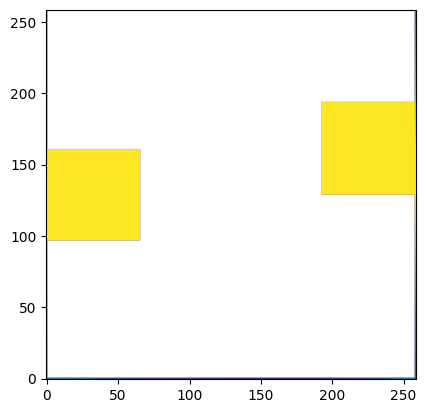

In [52]:
n = 256
bc = DirichletBoundaryCondition.empty_w_size(n+1, n+1)

bc.bottom[:n//2] = torch.linspace(13, 5, n//2)
bc.bottom[n//2:3*n//4] = 5
bc.bottom[3*n//4:] = torch.linspace(5, 13, n//4+1)

bc.top = 21

bc.left[:3*n//8] = torch.linspace(13, 40, 3*n//8)
bc.left[3*n//8:n//2+1] = 40
bc.left[n//2+1:] = torch.linspace(40, 21, n//2)

bc.right[:n//2] = torch.linspace(13, 40, n//2)
bc.right[n//2:5*n//8+1] = 40
bc.right[5*n//8+1:] = torch.linspace(40, 21, 3*n//8)

bc[3*n//8:5*n//8, :n//4+1] = 40
bc[n//2:6*n//8+1, 6*n//8:] = 40

bc.show()

In [53]:
coarse_sol = laplace_jacobi_smoothen(restrict2d(restrict2d(restrict2d(restrict2d(torch.full((257, 257), bc.mean().item()))))), bc.restrict().restrict().restrict().restrict(), tol=1e-5)

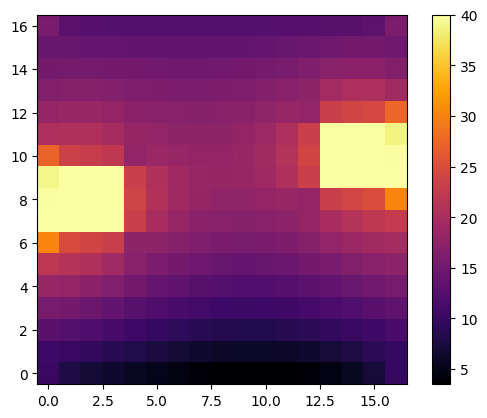

In [58]:
plt.imshow(coarse_sol, origin='lower', cmap='inferno')
plt.colorbar()

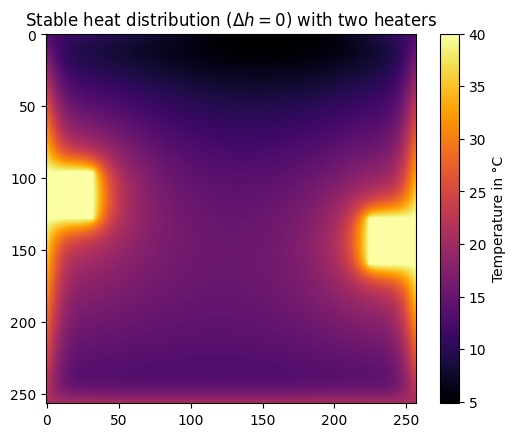

In [39]:
# f_smooth = laplace_full_multigrid_v_cycle(torch.full((257, 257), bc.mean().item()), bc, depth=4, tol=1e-4, maxiter=200)
f_smooth = laplace_multigrid_half_v_cycle(torch.full((257, 257), bc.mean().item()), bc, depth=4, tol=1e-4, maxiter=200)
plt.imshow(f_smooth, cmap='inferno')
plt.colorbar(label='Temperature in °C')
plt.title('Stable heat distribution ($\\Delta h = 0$) with two heaters')
plt.show()

In [61]:
n = 65
bc = DirichletBoundaryCondition.empty_w_size(n, n)

In [62]:
bc.left = 2

In [63]:
bc.top = torch.linspace(2, -2, 65)

In [64]:
bc.right[32:] = -2

In [65]:
bc[4*4:4*7, 4*8:4*12] = 4

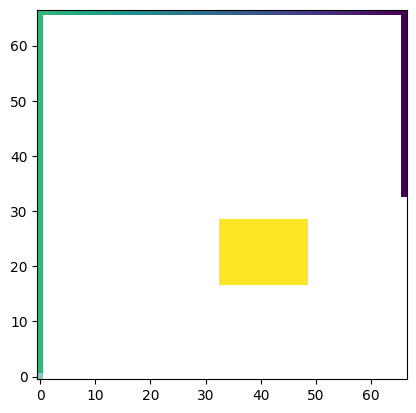

In [66]:
bc.show()

In [67]:
f = torch.full((65, 65), bc.mean().item())

In [20]:
from utils import interpolate, convT2d, interp_kernel_2d

In [21]:
convT2d(torch.zeros(2, 2), interp_kernel_2d)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])

In [74]:
f = laplace_multigrid_half_v_cycle(f, bc, tol=1e-6, maxiter=50000)

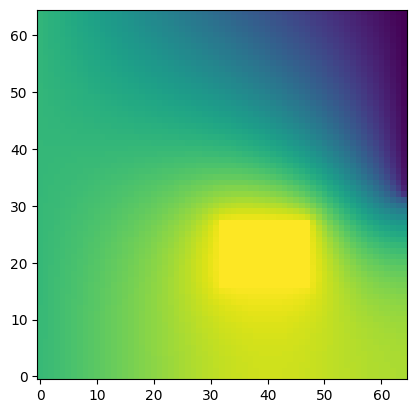

In [75]:
plt.imshow(f, origin='lower')